# DTAF: Dual-branch Temporal-Frequency Fusion for Time Series Forecasting

**Paper**: *Non-stationary Time Series Forecasting via Dual-branch Modeling with Temporal Fusion and Frequency Differencing* (AAAI 2026, Lu et al.)

**Key ideas**:
- **Dual-branch architecture**: Temporal branch (TFS) + Frequency branch (FWM) process patches in parallel
- **Non-stationary MOE Filter**: KAN-based Mixture of Experts extracts and subtracts non-stationary patterns from patches
- **KAN (Kolmogorov-Arnold Networks)**: B-spline basis function networks replace standard MLPs in the MOE router and experts
- **Temporal Fusion (TFS)**: Causal weighted aggregation of historical patches + gated current-patch contribution
- **Frequency Wave Modeling (FWM)**: FFT → frequency differencing between consecutive patches → TopK selection → iFFT
- **Training**: L1 loss + KL stationarity loss on stabilized patches + R-drop regularization (two forward passes)

This notebook is self-contained and uses random tensor data. Replace the dataset with real station data (e.g., Delhi hourly) for actual forecasting.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Configuration

Patch parameters control the input segmentation: `patch_len=16` with `stride=8` gives overlapping patches.
The MOE uses `expert_num=2` KAN experts with hidden dimension `d_model // kan_div`.
FWM selects `k=1` most-changing frequency components per patch.

In [2]:
class Config:
    seq_len = 96
    pred_len = 24
    enc_in = 7
    c_out = 7

    patch_len = 16
    stride = 8

    d_model = 32
    e_layers = 1
    heads = 2
    dropout = 0.1

    expert_num = 2
    kan_div = 4

    k = 1

    moving_avg = 25
    aggregated_norm = 1

    batch_size = 32
    lr = 1e-4
    num_epochs = 50
    alpha_kl = 1.0
    beta_rdrop = 0.1
    sigma_mixup = 1.0

    n_train = 800
    n_val = 100
    n_test = 100

config = Config()
config.patch_num = int((config.seq_len - config.patch_len) / config.stride + 2)
print(f'Input: ({config.seq_len}, {config.enc_in}) -> Forecast: ({config.pred_len}, {config.c_out})')
print(f'Patches: {config.patch_num} of size {config.patch_len}, stride {config.stride}')
print(f'MOE: {config.expert_num} KAN experts, TopK={config.k} frequencies')

Input: (96, 7) -> Forecast: (24, 7)
Patches: 12 of size 16, stride 8
MOE: 2 KAN experts, TopK=1 frequencies


## Dataset

Generate synthetic multivariate time series with trends, seasonality, and noise.
Each sample maps `seq_len` input steps to `pred_len` target steps.

In [3]:
class SyntheticTimeSeriesDataset(Dataset):
    def __init__(self, n_samples, seq_len, pred_len, n_vars):
        super().__init__()
        total_len = seq_len + pred_len
        t = np.linspace(0, 4 * np.pi, total_len)

        self.inputs = []
        self.targets = []
        for _ in range(n_samples):
            channels = []
            for v in range(n_vars):
                freq = np.random.uniform(0.5, 2.0)
                phase = np.random.uniform(0, 2 * np.pi)
                trend = np.random.uniform(-0.3, 0.3) * np.linspace(0, 1, total_len)
                seasonal = np.sin(freq * t + phase) + 0.5 * np.sin(2 * freq * t + phase / 2)
                noise = np.random.randn(total_len) * 0.1
                channels.append(trend + seasonal + noise)
            data = np.stack(channels, axis=-1).astype(np.float32)
            self.inputs.append(data[:seq_len])
            self.targets.append(data[seq_len:])

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return torch.from_numpy(self.inputs[idx]), torch.from_numpy(self.targets[idx])

train_ds = SyntheticTimeSeriesDataset(config.n_train, config.seq_len, config.pred_len, config.enc_in)
val_ds   = SyntheticTimeSeriesDataset(config.n_val, config.seq_len, config.pred_len, config.enc_in)
test_ds  = SyntheticTimeSeriesDataset(config.n_test, config.seq_len, config.pred_len, config.enc_in)

train_loader = DataLoader(train_ds, batch_size=config.batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=config.batch_size)
test_loader  = DataLoader(test_ds, batch_size=config.batch_size)

x_sample, y_sample = train_ds[0]
print(f'Input shape: {x_sample.shape}, Target shape: {y_sample.shape}')

Input shape: torch.Size([96, 7]), Target shape: torch.Size([24, 7])


## KAN: Kolmogorov-Arnold Networks

KAN replaces standard linear layers with learnable B-spline activation functions.
Each `KANLinear` computes: `output = SiLU(x) @ base_weight + B_spline(x) @ spline_weight`.
The B-spline basis provides smooth, learnable nonlinear transformations.
Used as MOE experts and the MOE router.

In [4]:
class KANLinear(nn.Module):
    def __init__(self, in_features, out_features, grid_size=5, spline_order=3,
                 scale_noise=0.1, scale_base=1.0, scale_spline=1.0,
                 base_activation=nn.SiLU, grid_range=(-1, 1)):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order

        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = (
            (torch.arange(-spline_order, grid_size + spline_order + 1) * h + grid_range[0])
            .expand(in_features, -1).contiguous()
        )
        self.register_buffer('grid', grid)

        self.base_weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.spline_weight = nn.Parameter(
            torch.Tensor(out_features, in_features, grid_size + spline_order)
        )
        self.spline_scaler = nn.Parameter(torch.Tensor(out_features, in_features))

        self.scale_noise = scale_noise
        self.scale_base = scale_base
        self.scale_spline = scale_spline
        self.base_activation = base_activation()

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5) * self.scale_base)
        with torch.no_grad():
            noise = (
                (torch.rand(self.grid_size + 1, self.in_features, self.out_features) - 0.5)
                * self.scale_noise / self.grid_size
            )
            self.spline_weight.data.copy_(
                self.curve2coeff(
                    self.grid.T[self.spline_order:-self.spline_order], noise
                )
            )
            nn.init.kaiming_uniform_(self.spline_scaler, a=math.sqrt(5) * self.scale_spline)

    def b_splines(self, x):
        assert x.dim() == 2 and x.size(1) == self.in_features
        grid = self.grid
        x = x.unsqueeze(-1)
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
        for k in range(1, self.spline_order + 1):
            bases = (
                (x - grid[:, :-(k + 1)]) / (grid[:, k:-1] - grid[:, :-(k + 1)]) * bases[:, :, :-1]
            ) + (
                (grid[:, k + 1:] - x) / (grid[:, k + 1:] - grid[:, 1:(-k)]) * bases[:, :, 1:]
            )
        return bases.contiguous()

    def curve2coeff(self, x, y):
        A = self.b_splines(x).transpose(0, 1)
        B = y.transpose(0, 1)
        solution = torch.linalg.lstsq(A, B).solution
        return solution.permute(2, 0, 1).contiguous()

    @property
    def scaled_spline_weight(self):
        return self.spline_weight * self.spline_scaler.unsqueeze(-1)

    def forward(self, x):
        original_shape = x.shape
        x = x.reshape(-1, self.in_features)
        base_output = F.linear(self.base_activation(x), self.base_weight)
        spline_output = F.linear(
            self.b_splines(x).view(x.size(0), -1),
            self.scaled_spline_weight.view(self.out_features, -1),
        )
        output = base_output + spline_output
        return output.reshape(*original_shape[:-1], self.out_features)


class KAN(nn.Module):
    def __init__(self, layers_hidden, **kwargs):
        super().__init__()
        self.layers = nn.ModuleList([
            KANLinear(in_f, out_f, **kwargs)
            for in_f, out_f in zip(layers_hidden, layers_hidden[1:])
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

print('KANLinear + KAN defined')

KANLinear + KAN defined


## Series Decomposition & Linear Extractor

**Series decomposition** (from Autoformer): Moving average separates trend from seasonal component.

**Linear extractor** (DLinear-style): Applies separate linear transforms to trend and seasonal, then sums.
Used inside TFS to extract features from historical and current patches.

In [5]:
class MovingAvg(nn.Module):
    def __init__(self, kernel_size, stride=1):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1)).permute(0, 2, 1)
        return x


class SeriesDecomp(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.moving_avg = MovingAvg(kernel_size, stride=1)

    def forward(self, x):
        trend = self.moving_avg(x)
        seasonal = x - trend
        return seasonal, trend


class LinearExtractor(nn.Module):
    def __init__(self, d_model, moving_avg_kernel):
        super().__init__()
        self.decomposition = SeriesDecomp(moving_avg_kernel)
        self.linear_seasonal = nn.Linear(d_model, d_model)
        self.linear_trend = nn.Linear(d_model, d_model)
        nn.init.constant_(self.linear_seasonal.weight, 1.0 / d_model)
        nn.init.constant_(self.linear_trend.weight, 1.0 / d_model)

    def forward(self, x):
        seasonal, trend = self.decomposition(x)
        return self.linear_seasonal(seasonal) + self.linear_trend(trend)

print('SeriesDecomp + LinearExtractor defined')

SeriesDecomp + LinearExtractor defined


## Patch Embedding

Segments input into overlapping patches via `ReplicationPad1d` + `unfold`, then projects each patch
from `patch_len` to `d_model` dimensions. Adds sinusoidal positional encoding.
Processing is **channel-independent**: batch dimension becomes `B * n_vars`.

In [6]:
class PositionalEmbedding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).float().unsqueeze(1)
        div_term = (torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model)).exp()
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.pe[:, :x.size(1)]


class PatchEmbedding(nn.Module):
    def __init__(self, d_model, patch_len, stride, padding, dropout):
        super().__init__()
        self.patch_len = patch_len
        self.stride = stride
        self.padding_layer = nn.ReplicationPad1d((0, padding))
        self.value_embedding = nn.Linear(patch_len, d_model, bias=False)
        self.position_embedding = PositionalEmbedding(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (B, D, L)
        n_vars = x.shape[1]
        x = self.padding_layer(x)
        x = x.unfold(dimension=-1, size=self.patch_len, step=self.stride)
        # x: (B, D, patch_num, patch_len)
        x = x.reshape(x.shape[0] * x.shape[1], x.shape[2], x.shape[3])
        # x: (B*D, patch_num, patch_len)
        x = self.value_embedding(x) + self.position_embedding(x)
        return self.dropout(x), n_vars

print('PatchEmbedding defined')

PatchEmbedding defined


## Non-stationary MOE Filter + Temporal Stabilizing Fusion (TFS)

**MOE Filter**: A KAN-based Mixture of Experts. The router (KANLinear) produces softmax weights over experts.
Each expert is a KAN network `[d_model → d_model//div → d_model]`. The MOE output captures non-stationary
patterns, which are *subtracted* from the input to produce stabilized patches.

**TFS**: After stabilization:
1. `LinearExtractor` extracts features from stabilized patches
2. Causal weight matrix (lower-triangular) aggregates historical patches
3. MLP transforms aggregated features → `H_history`
4. Gate mechanism on original patches → `H_current`
5. Output = LayerNorm(H_history + H_current)

In [7]:
class Expert(nn.Module):
    def __init__(self, input_dim, div):
        super().__init__()
        self.network = KAN(layers_hidden=[input_dim, input_dim // div, input_dim])

    def forward(self, x):
        return self.network(x)


class MOE(nn.Module):
    def __init__(self, expert_num, input_dim, div):
        super().__init__()
        self.router = KANLinear(input_dim, expert_num)
        self.experts = nn.ModuleList([Expert(input_dim, div) for _ in range(expert_num)])

    def forward(self, x):
        # x: (B*D, patch_num, d_model)
        router_weights = self.router(x).softmax(-1)  # (B*D, patch_num, expert_num)
        experts_out = torch.stack([expert(x) for expert in self.experts], dim=-2)
        # experts_out: (B*D, patch_num, expert_num, d_model)
        return torch.einsum('bpn,bpnd->bpd', router_weights, experts_out)


class TFS(nn.Module):
    def __init__(self, d_model, patch_num, config):
        super().__init__()
        self.config = config
        self.mlp = nn.Linear(d_model, d_model)
        self.extractor_his = LinearExtractor(d_model, config.moving_avg)
        self.weight_linear = nn.Linear(d_model, patch_num)
        self.dropout = nn.Dropout(config.dropout)
        self.extractor_cur = LinearExtractor(d_model, config.moving_avg)
        self.gate = nn.Linear(d_model, 1)
        if config.aggregated_norm == 1:
            self.norm = nn.LayerNorm(d_model)
        if config.expert_num > 0:
            self.moe = MOE(config.expert_num, d_model, config.kan_div)

    def forward(self, x):
        # x: (B*D, patch_num, d_model)
        origin = x

        # Non-stationary MOE filter: subtract non-stationary patterns
        if self.config.expert_num > 0:
            x = x - self.moe(x)

        stables = x  # stabilized patches (for KL loss)

        # Historical feature extraction + causal aggregation
        H = self.extractor_his(x)
        weight = self.weight_linear(H).softmax(dim=-1)  # (B*D, N, N)
        adj = torch.tril(weight, diagonal=0)  # causal mask
        aggregated = torch.matmul(adj, x)  # (B*D, N, d_model)
        H_history = self.dropout(self.mlp(aggregated))

        # Current patch gating
        gate_val = self.gate(self.extractor_cur(origin))  # (B*D, N, 1)
        H_current = self.dropout(gate_val.expand_as(origin)) * x

        out = H_history + H_current
        if self.config.aggregated_norm == 1:
            out = self.norm(out)

        return out, stables

print('Expert + MOE + TFS defined')

Expert + MOE + TFS defined


## Attention & Predictor

**Attention**: Standard multi-head self-attention with residual connection and LayerNorm.
Two instances: `temporal_attention` for H_t (from TFS) and `frequency_attention` for H_f (from FWM).

**Predictor**: Flattens the concatenated dual-branch features `[H_t, H_f]` and projects to `pred_len`.

In [8]:
class Attention(nn.Module):
    def __init__(self, d_model, heads, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=heads, dropout=dropout, batch_first=True
        )
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, _ = self.attention(x, x, x)
        x = x + self.dropout(attn_out)
        return self.norm(x)


class Predict(nn.Module):
    def __init__(self, nf, pred_len, dropout=0.0):
        super().__init__()
        self.flatten = nn.Flatten(start_dim=-2)
        self.linear = nn.Linear(nf, pred_len)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(self.linear(self.flatten(x)))

print('Attention + Predict defined')

Attention + Predict defined


## DTAF Model

Full forward pass:
1. **Instance Normalization**: Remove per-sample mean/std
2. **Patch & Embed**: Segment into overlapping patches, project to d_model
3. **TFS** (temporal branch): MOE filter → causal aggregation → residual connection
4. **FWM** (frequency branch): FFT → patch-to-patch amplitude differencing → TopK selection → iFFT
5. **Dual-branch Attention**: Separate self-attention on temporal and frequency features
6. **Concatenate & Predict**: Flatten `[H_t, H_f]` → linear projection to `pred_len`
7. **De-normalize**: Restore original scale

In [9]:
class DTAF(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.patch_num = int((config.seq_len - config.patch_len) / config.stride + 2)

        self.patch_embedding = PatchEmbedding(
            config.d_model, config.patch_len, config.stride, config.stride, config.dropout
        )
        self.TFS_layers = nn.ModuleList([
            TFS(config.d_model, self.patch_num, config)
            for _ in range(config.e_layers)
        ])
        self.temporal_attention = Attention(config.d_model, config.heads, config.dropout)
        self.frequency_attention = Attention(config.d_model, config.heads, config.dropout)
        self.predictor = Predict(
            2 * config.d_model * self.patch_num, config.pred_len, config.dropout
        )
        self.drop = nn.Dropout(config.dropout)
        self.norm = nn.LayerNorm(config.d_model)

    def _instance_norm(self, x):
        means = x.mean(1, keepdim=True)
        x = x - means
        stdev = torch.sqrt(x.var(dim=1, keepdim=True, unbiased=False) + 1e-5)
        x = x / stdev
        return x, means, stdev

    def forward(self, x_enc):
        B, L, D = x_enc.size()

        # 1. Instance normalization
        x_enc, means, stdev = self._instance_norm(x_enc)

        # 2. Patch & embed (channel-independent)
        enc_out, _ = self.patch_embedding(x_enc.transpose(1, 2))  # (B*D, N, d_model)

        # 3. TFS (temporal branch)
        enc_out_t = enc_out
        for tfs in self.TFS_layers:
            agg, stables = tfs(enc_out_t)
            enc_out_t = self.norm(self.drop(agg) + enc_out_t)  # residual

        # 4. FWM (frequency branch)
        H_t = enc_out_t
        freq = torch.fft.rfft(enc_out_t)  # (B*D, N, d_model//2+1) complex
        wave = torch.zeros(freq.shape[0], freq.shape[1], freq.shape[2], device=x_enc.device)
        wave[:, 1:, :] = torch.exp(
            torch.abs(freq[:, 1:, :]) - torch.abs(freq[:, :-1, :])
        )
        _, topk_indices = torch.topk(wave, self.config.k, dim=-1)
        mask = torch.zeros_like(freq, dtype=torch.bool)
        mask.scatter_(dim=-1, index=topk_indices, value=True)
        filtered_freq = torch.where(mask, freq, torch.zeros_like(freq))
        H_f = torch.fft.irfft(filtered_freq, n=enc_out_t.shape[-1])
        H_f[:, 0, :] = enc_out_t[:, 0, :]  # first patch: no diff available

        # 5. Dual-branch attention
        H_t = self.temporal_attention(H_t)
        H_f = self.frequency_attention(H_f)
        enc_out = torch.cat([H_t, H_f], dim=-2)  # (B*D, 2*N, d_model)

        # 6. Predict
        enc_out = enc_out.reshape(-1, D, enc_out.shape[-2], enc_out.shape[-1])
        enc_out = enc_out.permute(0, 1, 3, 2)  # (B, D, d_model, 2*N)
        out = self.predictor(enc_out)  # (B, D, pred_len)
        out = out.permute(0, 2, 1)  # (B, pred_len, D)

        # 7. De-normalize
        out = out * stdev[:, 0, :].unsqueeze(1).expand_as(out)
        out = out + means[:, 0, :].unsqueeze(1).expand_as(out)

        return out, stables

model = DTAF(config).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'DTAF model: {n_params:,} trainable parameters')

with torch.no_grad():
    test_x = torch.randn(2, config.seq_len, config.enc_in, device=device)
    test_out, test_stables = model(test_x)
    print(f'Forward pass: ({test_x.shape}) -> prediction {test_out.shape}, stables {test_stables.shape}')

DTAF model: 44,261 trainable parameters
Forward pass: (torch.Size([2, 96, 7])) -> prediction torch.Size([2, 24, 7]), stables torch.Size([14, 12, 32])


## Training

The training loss combines three terms:
1. **Task loss (L1/MAE)**: Prediction accuracy — computed on both forward passes
2. **KL stationarity loss**: Pairwise KL divergence between patch distributions (softmax over d_model). Encourages the MOE filter to produce stationary patches
3. **R-drop loss (MSE)**: Consistency between two forward passes with different dropout masks

**Channel mixup** augments training data by mixing random channel permutations with Gaussian weights.

In [10]:
def kl_stationarity_loss(stables):
    """Pairwise KL divergence between all patch distributions to encourage stationarity."""
    probs = stables.softmax(dim=-1)  # (B*D, N, d_model) -> probability distributions
    log_probs = torch.log(probs + 1e-8)
    p_i = probs.unsqueeze(2)       # (B*D, N, 1, d_model)
    log_p_i = log_probs.unsqueeze(2)
    log_q_j = log_probs.unsqueeze(1)  # (B*D, 1, N, d_model)
    kl = (p_i * (log_p_i - log_q_j)).sum(dim=-1)  # (B*D, N, N)
    return kl.mean()


def channel_mixup(x, y, sigma=1.0):
    """Data augmentation: mix channels with Gaussian-weighted random permutations."""
    B, L, D = x.shape
    H = y.shape[1]
    perm = torch.randint(0, D, (B, D), device=x.device).unsqueeze(1)
    lam = torch.randn(B, D, device=x.device).unsqueeze(1) * sigma
    x_perm = x.gather(-1, perm.expand(B, L, D))
    y_perm = y.gather(-1, perm.expand(B, H, D))
    return x + lam * x_perm, y + lam * y_perm


def train_epoch(model, loader, optimizer, config):
    model.train()
    total_loss = 0
    criterion = nn.L1Loss()

    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        x_batch, y_batch = channel_mixup(x_batch, y_batch, config.sigma_mixup)

        # Two forward passes (R-drop: different dropout masks)
        out1, stables1 = model(x_batch)
        out2, stables2 = model(x_batch)

        # Task loss
        task_loss = criterion(out1, y_batch) + criterion(out2, y_batch) / 2

        # R-drop consistency loss
        rdrop_loss = config.beta_rdrop * F.mse_loss(out1, out2)

        # KL stationarity loss
        kl_loss = config.alpha_kl * (
            kl_stationarity_loss(stables1) + kl_stationarity_loss(stables2) / 2
        )

        loss = task_loss + rdrop_loss + kl_loss

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_mae, total_mse, n = 0, 0, 0
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        pred, _ = model(x_batch)
        total_mae += F.l1_loss(pred, y_batch, reduction='sum').item()
        total_mse += F.mse_loss(pred, y_batch, reduction='sum').item()
        n += y_batch.numel()
    return total_mae / n, total_mse / n

print('Training utilities defined')

Training utilities defined


In [11]:
model = DTAF(config).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=config.lr)

best_val_mae = float('inf')
patience_counter = 0
patience = 5
train_losses = []

for epoch in range(1, config.num_epochs + 1):
    train_loss = train_epoch(model, train_loader, optimizer, config)
    val_mae, val_mse = evaluate(model, val_loader)
    train_losses.append(train_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Val MAE: {val_mae:.4f} | Val MSE: {val_mse:.4f}')

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch}')
            break

model.load_state_dict(best_state)
model = model.to(device)
test_mae, test_mse = evaluate(model, test_loader)
print(f'\nTest MAE: {test_mae:.4f} | Test MSE: {test_mse:.4f}')

Epoch   1 | Train Loss: 2.2095 | Val MAE: 0.7258 | Val MSE: 0.7488
Epoch   5 | Train Loss: 1.7658 | Val MAE: 0.5644 | Val MSE: 0.4805
Epoch  10 | Train Loss: 1.5018 | Val MAE: 0.4744 | Val MSE: 0.3644
Epoch  15 | Train Loss: 1.3659 | Val MAE: 0.4546 | Val MSE: 0.3399
Epoch  20 | Train Loss: 1.2925 | Val MAE: 0.4468 | Val MSE: 0.3288
Epoch  25 | Train Loss: 1.2206 | Val MAE: 0.4361 | Val MSE: 0.3155
Epoch  30 | Train Loss: 1.1891 | Val MAE: 0.4287 | Val MSE: 0.3047
Epoch  35 | Train Loss: 1.1649 | Val MAE: 0.4192 | Val MSE: 0.2930
Epoch  40 | Train Loss: 1.1386 | Val MAE: 0.4122 | Val MSE: 0.2838
Epoch  45 | Train Loss: 1.1036 | Val MAE: 0.4031 | Val MSE: 0.2726
Epoch  50 | Train Loss: 1.0921 | Val MAE: 0.3940 | Val MSE: 0.2619

Test MAE: 0.3973 | Test MSE: 0.2641


## Visualization

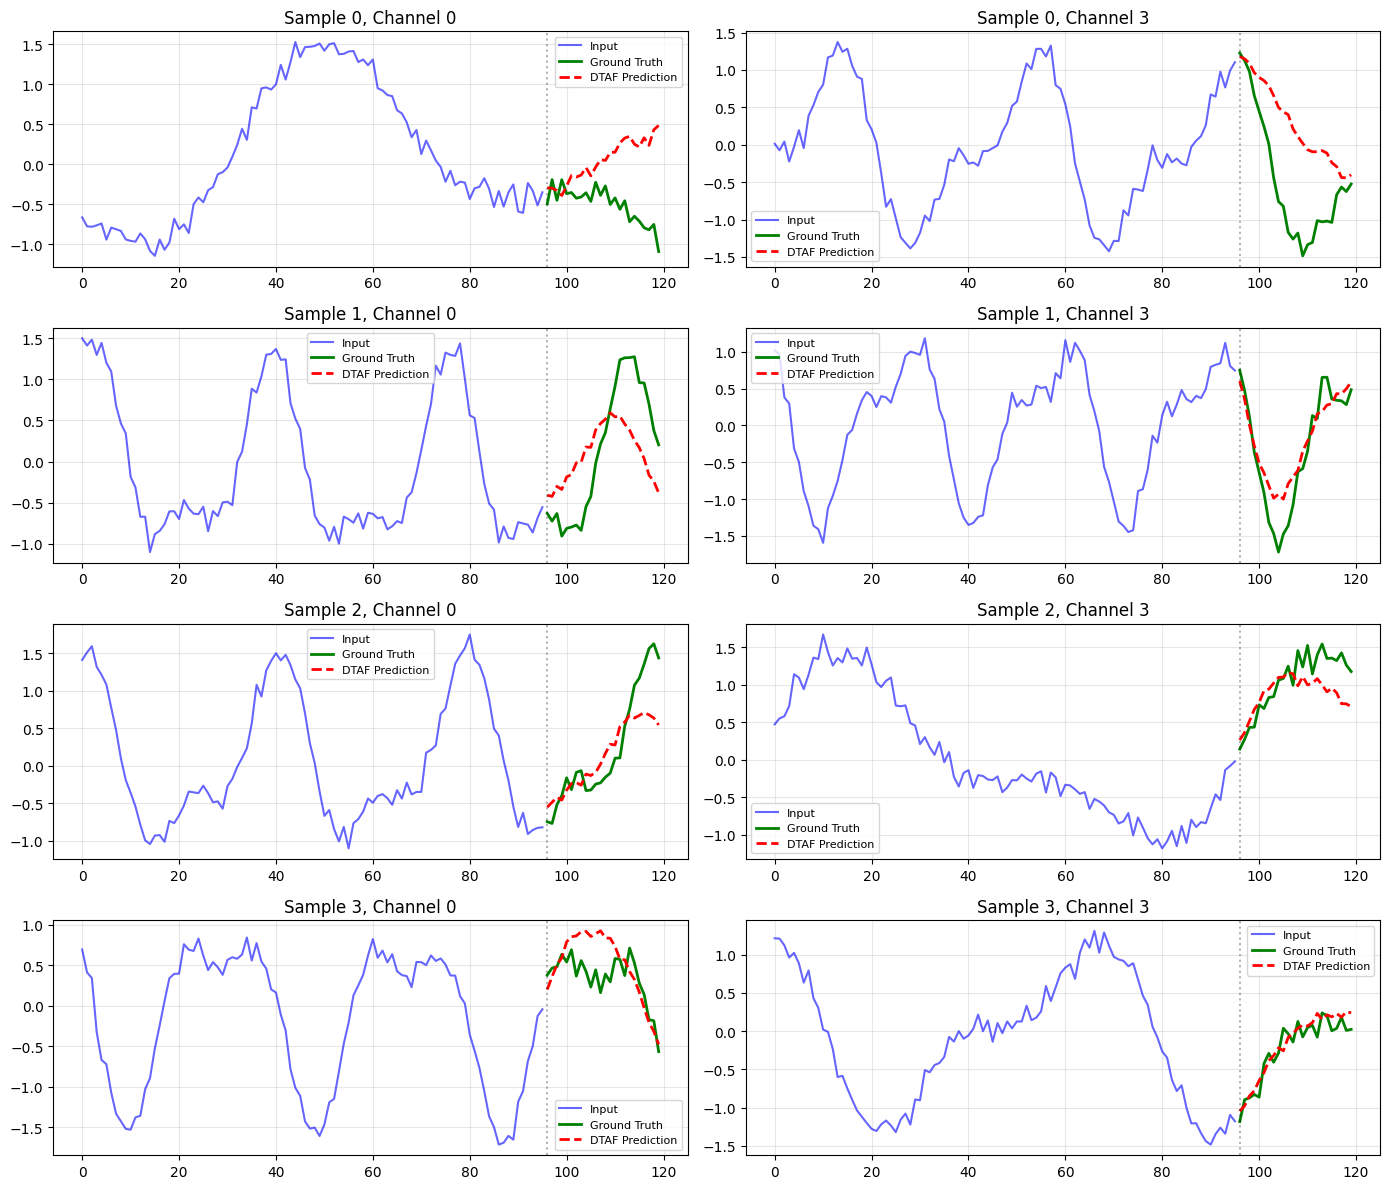

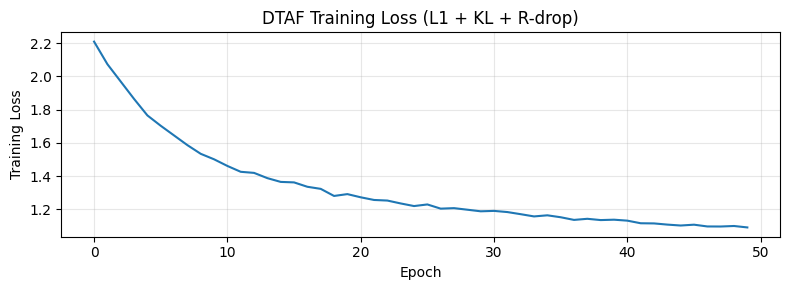

In [12]:
model.eval()
n_show = 4
fig, axes = plt.subplots(n_show, 2, figsize=(14, 3 * n_show))

for i in range(n_show):
    x_in, y_true = test_ds[i]
    x_in_dev = x_in.unsqueeze(0).to(device)
    with torch.no_grad():
        y_pred, _ = model(x_in_dev)
    y_pred = y_pred.squeeze(0).cpu().numpy()
    x_np = x_in.numpy()
    y_np = y_true.numpy()

    for col, ch in enumerate([0, min(3, config.enc_in - 1)]):
        ax = axes[i, col]
        t_input = np.arange(config.seq_len)
        t_pred = np.arange(config.seq_len, config.seq_len + config.pred_len)
        ax.plot(t_input, x_np[:, ch], 'b-', alpha=0.6, label='Input')
        ax.plot(t_pred, y_np[:, ch], 'g-', linewidth=2, label='Ground Truth')
        ax.plot(t_pred, y_pred[:, ch], 'r--', linewidth=2, label='DTAF Prediction')
        ax.axvline(x=config.seq_len, color='k', linestyle=':', alpha=0.3)
        ax.set_title(f'Sample {i}, Channel {ch}')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Training loss curve
plt.figure(figsize=(8, 3))
plt.plot(train_losses)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('DTAF Training Loss (L1 + KL + R-drop)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Adapting for Real Data

Replace `SyntheticTimeSeriesDataset` with your own data loader. For example, for Delhi hourly temperature:

```python
import pandas as pd

df = pd.read_csv('delhi_hourly.csv', parse_dates=['datetime'])
features = ['temperature', 'humidity', 'pressure', 'wind_speed']
data = df[features].values.astype(np.float32)

# Normalize
mean, std = data.mean(0), data.std(0)
data = (data - mean) / std

# Create sliding windows
class StationDataset(Dataset):
    def __init__(self, data, seq_len, pred_len):
        self.samples = []
        for i in range(len(data) - seq_len - pred_len + 1):
            self.samples.append((
                torch.from_numpy(data[i:i+seq_len]),
                torch.from_numpy(data[i+seq_len:i+seq_len+pred_len])
            ))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx]

# Update config
config.enc_in = config.c_out = len(features)
config.seq_len = 168   # 1 week hourly
config.pred_len = 24   # 1 day ahead
config.patch_num = int((config.seq_len - config.patch_len) / config.stride + 2)
```

Key tuning knobs:
- `patch_len` / `stride`: Adjust for your temporal resolution (16/8 for hourly, 24/12 for daily)
- `expert_num` / `kan_div`: More experts for highly non-stationary data
- `k`: Higher TopK for richer frequency dynamics
- `alpha_kl`: Increase if MOE filter isn't removing enough non-stationarity
- `moving_avg`: Match dominant periodicity (e.g., 25 for daily in hourly data)